In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from datasets import load_dataset

In [ ]:
load_dataset('dair-ai/emotion')

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [ ]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [ ]:
label_names = emotion_dataset['train'].features['label'].names

In [ ]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})
df_test = pd.DataFrame({
    'text': test_text,
    'label': [label_names[i] for i in test_label]
})

In [ ]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


<Axes: xlabel='label', ylabel='count'>

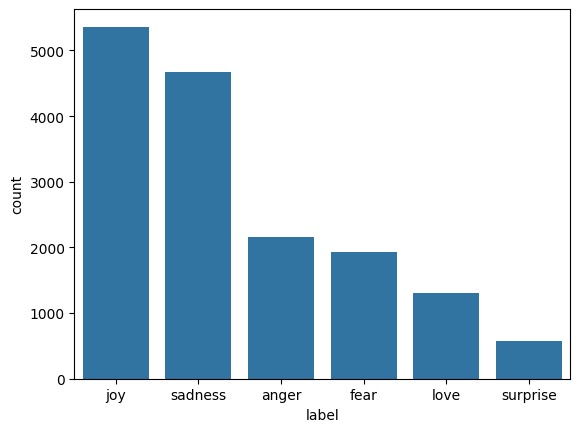

In [ ]:
sns.countplot(x='label', data=df_train,order=df_train.label.value_counts().index)
#

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

In [ ]:
padded_train_sequence = pad_sequences(train_sequence,maxlen= 50,padding='post',truncating='post')
padded_test_sequence = pad_sequences(test_sequence,maxlen= 50,padding='post',truncating='post')

In [ ]:
train_labels = np.array(train_label)
test_labels = np.array(test_label)
train_labels

array([0, 0, 3, ..., 1, 3, 0])

In [ ]:
num_classes = len(np.unique(train_labels))

In [ ]:
num_classes

6

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min',
    restore_best_weights=True
)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Embedding, LSTM, Dense, Dropout, Bidirectional,GRU

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    SimpleRNN(units=128), # Changed from return_sequences=True to False (default)
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:
model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights_dict,
)
rnn_loss , rnn_accuracy = model.evaluate(padded_test_sequence,test_labels)
print("Loss: ",rnn_loss)
print("Accuracy: ",rnn_accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1497 - loss: 1.8108 - val_accuracy: 0.2160 - val_loss: 1.7837
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1737 - loss: 1.7905 - val_accuracy: 0.1280 - val_loss: 1.7965
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1628 - loss: 1.7856 - val_accuracy: 0.1510 - val_loss: 1.7906
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1562 - loss: 1.7803 - val_accuracy: 0.1290 - val_loss: 1.7983
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2160 - loss: 1.7837
Loss:  1.7836730480194092
Accuracy:  0.2160000056028366


In [ ]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    LSTM(units=128, return_sequences=True), # Changed from return_sequences=True to False (default)
    Dropout(0.5),
    LSTM(units=64), # Changed from return_sequences=True to False (default)
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights_dict,
)

lstm_loss , lstm_accuracy = lstm_model.evaluate(padded_test_sequence,test_labels)
print("Loss: ",lstm_loss)
print("Accuracy: ",lstm_accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1537 - loss: 1.7953 - val_accuracy: 0.2820 - val_loss: 1.7921
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1482 - loss: 1.7940 - val_accuracy: 0.0955 - val_loss: 1.8011
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1560 - loss: 1.7922 - val_accuracy: 0.0335 - val_loss: 1.8080
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2820 - loss: 1.7921
Loss:  1.792093276977539
Accuracy:  0.28200000524520874


In [ ]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    GRU(units=128, return_sequences=True), # Changed from return_sequences=True to False (default)
    Dropout(0.5),
    GRU(units=64), # Changed from return_sequences=True to False (default)
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights_dict,
)

gru_loss , gru_accuracy = gru_model.evaluate(padded_test_sequence,test_labels)
print("Loss: ",gru_loss)
print("Accuracy: ",gru_accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.1561 - loss: 1.7964 - val_accuracy: 0.0805 - val_loss: 1.8224
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1422 - loss: 1.7958 - val_accuracy: 0.2900 - val_loss: 1.7754
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1621 - loss: 1.7943 - val_accuracy: 0.2900 - val_loss: 1.7776
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1643 - loss: 1.7943 - val_accuracy: 0.1375 - val_loss: 1.7986
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1488 - loss: 1.7877 - val_accuracy: 0.1130 - val_loss: 1.7715
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1961 - loss: 1.7644 - val_accuracy: 0.2625 - val_loss: 1.7926
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1970 - loss: 1.7336 - val_accuracy: 0.1035 - val_loss: 1.8444
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2122 - loss: 1.6677 - val_accur

In [ ]:
result_df = pd.DataFrame({
    "Model" : ['RNN','LSTM','GRU'],
    "Loss" : [rnn_loss,lstm_loss,gru_loss],
    "Accuracy" : [rnn_accuracy,lstm_accuracy,gru_accuracy]
}).sort_values(by='Accuracy',ascending = False)

In [ ]:
result_df

,Model,Loss,Accuracy
1,LSTM,1.792093,0.282
0,RNN,1.783673,0.216
2,GRU,1.771459,0.113


In [ ]:
BiLSTM = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50),
    Bidirectional(LSTM(units=128, return_sequences=True)), # Changed from return
    Dropout(0.5),
    Bidirectional(LSTM(units=64)), # Changed from return
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])
BiLSTM.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
BiLSTM.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiLSTM.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights_dict,
)

biLSTM_loss , biLSTM = BiLSTM.evaluate(padded_test_sequence,test_labels)
print("Loss: ",biLSTM_loss)
print("Accuracy: ",biLSTM)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9038 - loss: 0.2994 - val_accuracy: 0.8880 - val_loss: 0.3548
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9372 - loss: 0.1822 - val_accuracy: 0.9145 - val_loss: 0.2199
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9488 - loss: 0.1403 - val_accuracy: 0.9115 - val_loss: 0.2572
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8880 - loss: 0.3548
Loss:  0.8880000114440918
Accuracy:  0.8880000114440918


In [ ]:
BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50),
    Bidirectional(GRU(units=128, return_sequences=True)), # Changed from return
    Dropout(0.5),
    Bidirectional(GRU(units=64)), # Changed from return
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

BiGRU.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']

)
BiGRU.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights_dict,
)

bigru_loss , bigru_accuracy = BiGRU.evaluate(padded_test_sequence,test_labels)
print("Loss: ",bigru_loss)
print("Accuracy: ",bigru_accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5768 - loss: 1.0134 - val_accuracy: 0.8650 - val_loss: 0.4649
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9128 - loss: 0.2367 - val_accuracy: 0.9210 - val_loss: 0.1874
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9431 - loss: 0.1625 - val_accuracy: 0.9185 - val_loss: 0.2468
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9542 - loss: 0.1164 - val_accuracy: 0.9195 - val_loss: 0.2457
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9684 - loss: 0.0865 - val_accuracy: 0.9220 - val_loss: 0.2449
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9210 - loss: 0.1874
Loss:  0.18741849064826965
Accuracy:  0.9210000038146973


In [ ]:
bigru_accuracy

0.9210000038146973

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


Text(95.72222222222221, 0.5, 'True Labels')

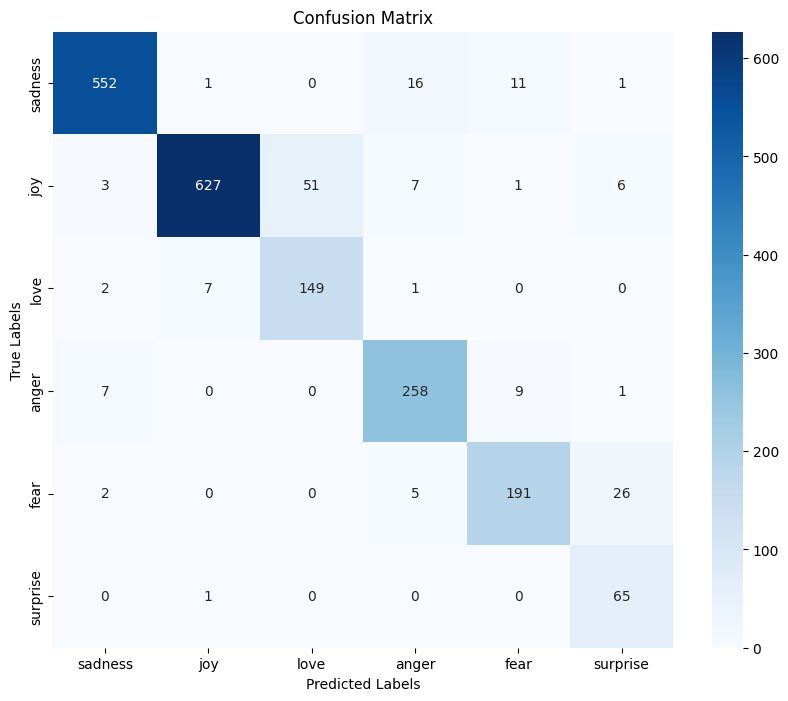

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = BiGRU.predict(padded_test_sequence)
BiGRU_predictions = np.argmax(BiGRU_predictions, axis=1)

cm = confusion_matrix(test_labels, BiGRU_predictions)
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

In [ ]:
sample_texts = [
    "I finally completed my project today, and I'm incredibly happy with how everything turned out!",
    "I tried my best, but things didn't work out, and now I feel really disappointed and alone.",
    "I've been waiting for hours, and nobody even bothered to tell me what was happening. This is so frustrating!",
    "I'm really nervous about tomorrow's exam. I keep thinking that I might forget everything when I sit down to write it.",
    "Spending time with the people I care about always makes me feel warm, peaceful, and grateful."
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = BiGRU.predict(sample_padded_sequences)
sample_predictions = np.argmax(sample_predictions, axis=1)

for text, label in zip(sample_texts, sample_predictions):
    print(f"Text: {text} --->  {label_names[label]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Text: I finally completed my project today, and I'm incredibly happy with how everything turned out! --->  anger
Text: I tried my best, but things didn't work out, and now I feel really disappointed and alone. --->  sadness
Text: I've been waiting for hours, and nobody even bothered to tell me what was happening. This is so frustrating! --->  anger
Text: I'm really nervous about tomorrow's exam. I keep thinking that I might forget everything when I sit down to write it. --->  fear
Text: Spending time with the people I care about always makes me feel warm, peaceful, and grateful. --->  joy


In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

#Save
BiGRU.save(os.path.join(model_dir,'BiGRU_Model.keras'))
with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as f:
    pickle.dump(tokenizer,f)